# TP2 - Machine learning for classification (Ensemble Methods)

In [10]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math

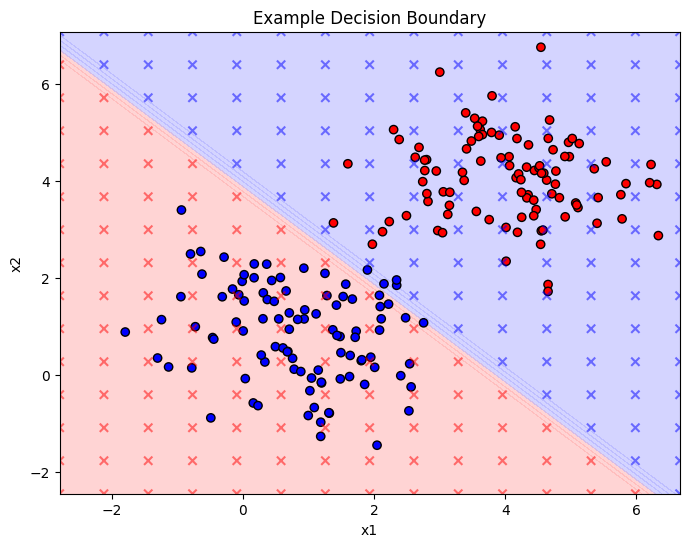

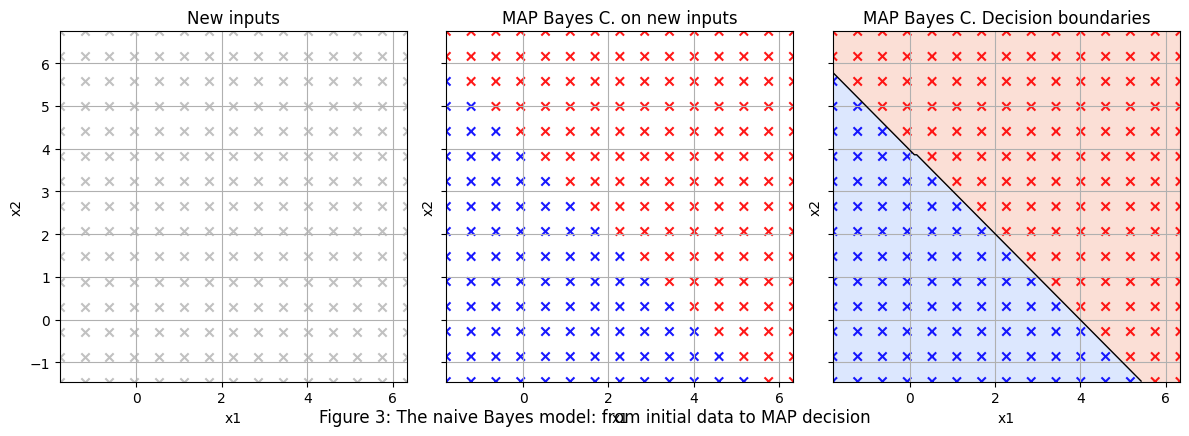

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def simulate_gaussian_2class(N=200, mean1=(1,0), mean2=(1,0), cov1=np.array([[1, 0], [0, 1]]), cov2=np.array([[1, 0], [0, 1]])):
    """
Génère un dataset 2D binaire de taille N (2 classes) :
    - Classe 0 : N(mu1, cov1^2 I)
    - Classe 1 : N(mu2, sigma^2 I)
    Retourne X (N,2) et Y (N,)
    """
    N1 = N // 2
    N2 = N - N1

    x1 = np.random.multivariate_normal(mean1, cov1, N1)
    y1 = np.ones(N1)
    x2 = np.random.multivariate_normal(mean2, cov2, N2)
    y2 = np.zeros(N2)

    X = np.vstack((x1, x2))
    Y = np.hstack((y1, y2))
    return X, Y


def grid_evaluation(X, Neval):
    x1, x2= X[:,0], X[:,1]
    x1_min,x1_max = min(x1)-1,max(x1)+1
    x2_min,x2_max = min(x2)-1,max(x2)+1
    h1, h2= (x1_max-x1_min)/Neval, (x2_max-x2_min)/Neval
    x1Grid,x2Grid=np.meshgrid(np.arange(x1_min,x1_max,h1),np.arange(x2_min,x2_max,h2))
    return x1Grid, x2Grid

def plot_decision_boundary(X, Y, model, Neval=100, title="Decision Boundary"):
    x1Grid, x2Grid = grid_evaluation(X, Neval)
    grid_points = np.c_[x1Grid.ravel(), x2Grid.ravel()]
    Z = np.array([model(point) for point in grid_points])
    Z = Z.reshape(x1Grid.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_points = ListedColormap(['r', 'b'])
    plt.figure(figsize=(8,6))
    plt.contourf(x1Grid, x2Grid, Z, alpha=0.5, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor='k', marker='o', cmap=cmap_points)
    plt.scatter(grid_points[:,0], grid_points[:,1], c=Z.ravel(), marker="x", alpha=0.5, cmap=cmap_points)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def plot_nb_map_figure(X, model, Neval=15, nx=150, ny=150,
                       suptitle="Figure 3: The naive Bayes model: from initial data to MAP decision"):
    """
    X      : données (n, 2)
    model  : fonction de prédiction binaire, ex. posterior_prob(x) -> 0 ou 1
    Neval  : taille de la petite grille de 'new_inputs'
    nx, ny : résolution de la grille dense pour la frontière
    """

    x1 = X[:, 0]
    x2 = X[:, 1]
    x1_min, x1_max = x1.min(), x1.max()
    x2_min, x2_max = x2.min(), x2.max()

    gx, gy = np.meshgrid(
        np.linspace(x1_min, x1_max, Neval),
        np.linspace(x2_min, x2_max, Neval)
    )
    new_inputs = np.c_[gx.ravel(), gy.ravel()]  # (Neval*Neval, 2)
    new_preds  = np.array([model(x) for x in new_inputs])  # 0/1

    # --- Grille dense pour visualiser la frontière ---
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, nx),
        np.linspace(x2_min, x2_max, ny)
    )
    grid_pts = np.c_[xx1.ravel(), xx2.ravel()]
    Z = np.array([model(x) for x in grid_pts]).reshape(xx1.shape)  # 0/1

    fig, axs = plt.subplots(1, 3, figsize=(12, 4.5), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.25)

    # (a) New inputs (gris)
    axs[0].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.6, c="0.6")
    axs[0].set_title("New inputs")
    axs[0].set_xlabel("x1")
    axs[0].set_ylabel("x2")
    axs[0].set_xlim(x1_min, x1_max)
    axs[0].set_ylim(x2_min, x2_max)
    axs[0].grid(True)
    axs[0].set_aspect("equal", adjustable="box")

    # (b) MAP Bayes classifier on new inputs (rouge/bleu)
    colors = np.where(new_preds == 1, "red", "blue")
    axs[1].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.9, c=colors)
    axs[1].set_title("MAP Bayes C. on new inputs")
    axs[1].set_xlabel("x1")
    axs[1].set_ylabel("x2")
    axs[1].grid(True)
    axs[1].set_aspect("equal", adjustable="box")

    # (c) Decision boundaries + points colorés
    axs[2].contourf(xx1, xx2, Z,
                    levels=[-0.5, 0.5, 1.5], alpha=0.3, cmap="coolwarm")
    axs[2].contour(xx1, xx2, Z,
                   levels=[0.5], colors="k", linewidths=1.0)  # frontière
    axs[2].scatter(new_inputs[:, 0], new_inputs[:, 1],
                   marker="x", alpha=0.9, c=colors)
    axs[2].set_title("MAP Bayes C. Decision boundaries")
    axs[2].set_xlabel("x1")
    axs[2].set_ylabel("x2")
    axs[2].grid(True)
    axs[2].set_aspect("equal", adjustable="box")

    plt.suptitle(suptitle, y=0.02)
    plt.tight_layout()
    plt.show()


# Exemple :
X, Y = simulate_gaussian_2class(N=200, mean1=(1,1), mean2=(4,4))
x1Grid, x2Grid = grid_evaluation(X, Neval=15)
plot_decision_boundary(X, Y, lambda x: 1 if x[0] + x[1] > 4 else 0, Neval=15, title="Example Decision Boundary")
plot_nb_map_figure(X, lambda x: 1 if x[0] + x[1] > 4 else 0, Neval=15, nx=150, ny=150)

Random Forest
 - Accuracy train : 0.995
 - OOB score : 0.985
 - Feature importances (x1, x2) : [0.47127224 0.52872776]


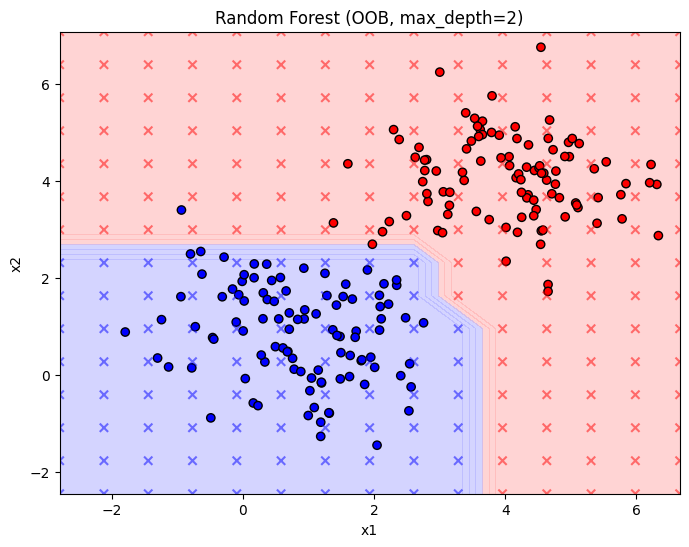

In [12]:
#Decision Tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text


RF = RandomForestClassifier(max_depth=2, random_state=0, oob_score=True)

RFfit = RF.fit(X, Y)

print("Random Forest")
print(" - Accuracy train :", RF.score(X, Y))
print(" - OOB score :", RF.oob_score_)
print(" - Feature importances (x1, x2) :", RF.feature_importances_)

plot_decision_boundary(X, Y, lambda x: RF.predict([x])[0], Neval=15, title="Random Forest (OOB, max_depth=2)")

# AdaBoost

AdaBoost
  - Train error : 0.000
  - Train accuracy : 1.000


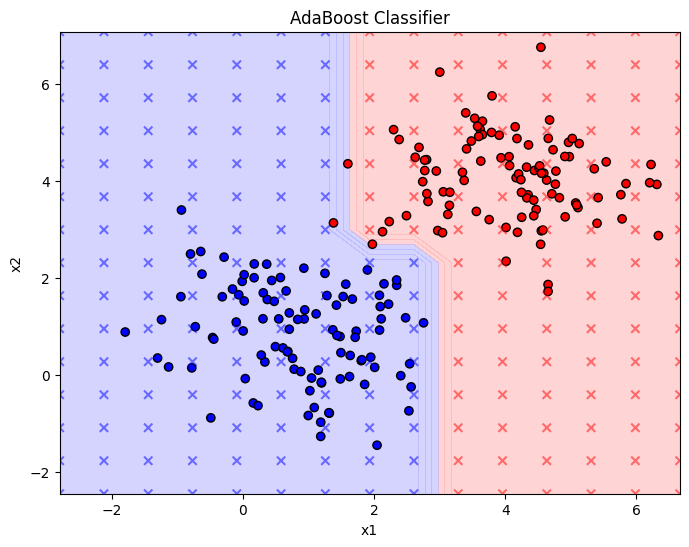

In [16]:
from sklearn.ensemble import AdaBoostClassifier

Ab = AdaBoostClassifier(n_estimators=100, random_state=0)

Abfit = Ab.fit(X, Y)

y_pred = Abfit.predict(X)
E_all = (Y != y_pred).sum() / len(Y)
print("AdaBoost")
print("  - Train error : %.3f" % E_all)
print("  - Train accuracy : %.3f" % accuracy_score(Y, y_pred))

plot_decision_boundary(X, Y, lambda x: Ab.predict([x])[0], Neval=15, title="AdaBoost Classifier")

# Structure of the successive Adaboost trees

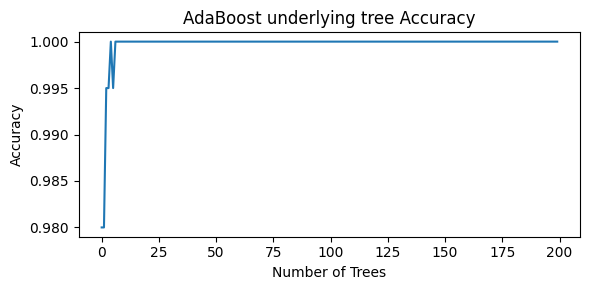

In [18]:
Ad = AdaBoostClassifier(
    n_estimators=200,
    random_state=0
)
Ad.fit(X, Y)

Ad_seq_acc = []
for y_pred_stage in Ad.staged_predict(X):
    Ad_seq_acc.append(metrics.accuracy_score(Y, y_pred_stage))

plt.figure(figsize=(6,3))
plt.plot(Ad_seq_acc)
plt.title('AdaBoost underlying tree Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


# Gradient Boosting

Gradient Boosting
  - Train error : 0.000
  - Train accuracy : 1.000


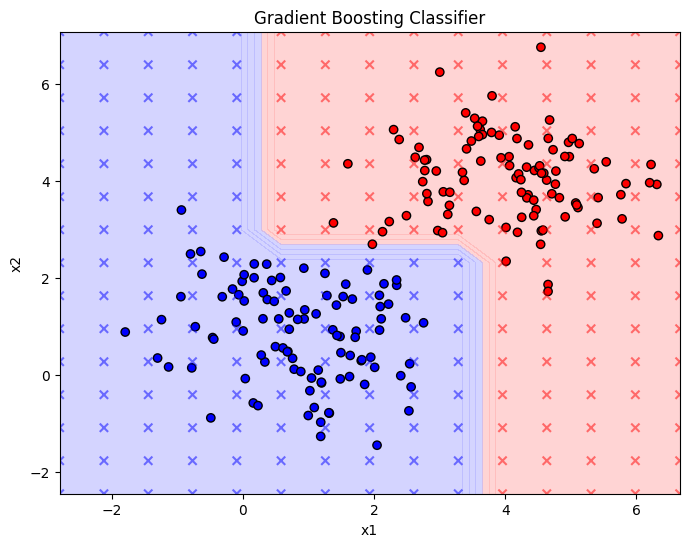

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

GB = GradientBoostingClassifier(random_state=0)
GBfit = GB.fit(X, Y)

y_pred = GBfit.predict(X)
E_all = (Y != y_pred).sum() / len(Y)
print("Gradient Boosting")
print(" - Train error : %.3f" % E_all)
print(" - Train accuracy : %.3f" % accuracy_score(Y, y_pred))

plot_decision_boundary(X, Y, lambda x: GB.predict([x])[0], Neval=15, title="Gradient Boosting Classifier")


## Structure of the successive Adaboost trees

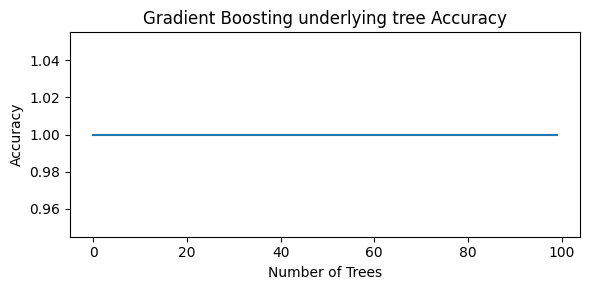

In [23]:
GB2 = GradientBoostingClassifier(random_state=0)
GB2.fit(X, Y)

GB_seq_acc = []
for y_pred_stage in GB2.staged_predict(X):
    GB_seq_acc.append(metrics.accuracy_score(Y, y_pred_stage))

plt.figure(figsize=(6,3))
plt.plot(GB_seq_acc)
plt.title('Gradient Boosting underlying tree Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


# Stacking


Stacking
 - Train accuracy : 1.0


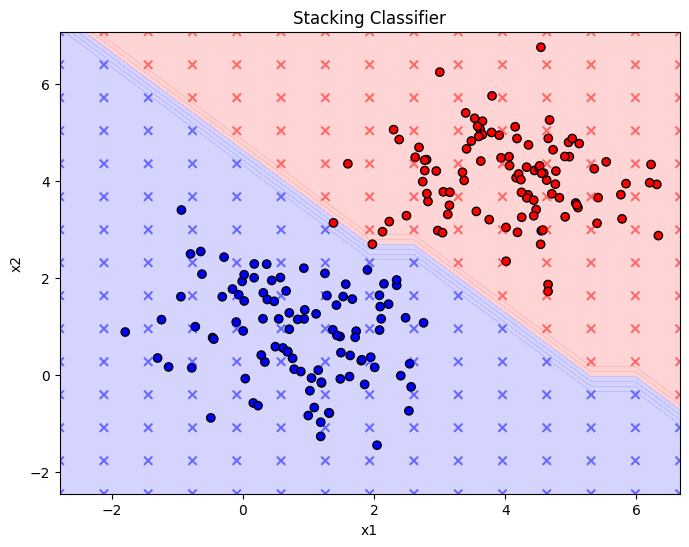

In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

base_estimators = [
    ('nb',   GaussianNB()),
    ('lda',  LinearDiscriminantAnalysis()),
    ('qda',  QuadraticDiscriminantAnalysis()),
    ('logr', LogisticRegression(max_iter=1000)),
    ('tree', DecisionTreeClassifier(max_depth=4, random_state=0))
]

stack_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='auto',
    n_jobs=-1
)

stack_clf.fit(X, Y)

print("Stacking")
print(" - Train accuracy :", stack_clf.score(X, Y))

plot_decision_boundary(X, Y, lambda x: stack_clf.predict([x])[0], Neval=15, title="Stacking Classifier")